In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

df = pd.read_csv("/Users/thunthita/LidarNRBPipeline/LIDar/csvfiles/05-02-2026/00.05.csv")
AfterPulse = pd.read_csv("/Users/thunthita/LidarNRBPipeline/LIDar/RawFile/AfterPulse.csv")
AfterPulse

,range_m,afterpulse_counts_per_bin,afterpulse_raw
0,0.00,0.0,0.0
1,3.75,0.0,0.0
2,7.50,0.0,0.0
3,11.25,0.0,0.0
4,15.00,0.0,0.0
...,...,...,...
4495,16856.25,NaN,NaN
4496,16860.00,NaN,NaN
4497,16863.75,NaN,NaN
4498,16867.50,NaN,NaN


In [2]:
#parameter

#note: blend region shold be wider than overlap about 50 unit to make a smooth line
config = {
    "bin_width_ns": 25,
    "bin_spacing_m": 3.75,
    "prf_hz": 20,
    "dead_time_ns": 3.06,
    "bg_start_m": 10000,
    "bg_end_m": 15000,
    "overlap_r1_m": 200,
    "overlap_r2_m": 300,
    "shift_search_bins": 20,
    "afterpulse_provided": True,
    # "k_scale": 0.064021849,
    # "b_offset": 0,
    "Energy": 25.51, #mJ
}


In [3]:
df

,analog,analog_sterr,photon_counting,pc_sterr,overflow_info
0,29.89530,0.174851,175.084000,0.892927,0.0
1,68.51770,0.405949,196.221000,0.878221,0.0
2,281.50300,2.349840,108.629000,1.375130,0.0
3,473.53200,0.066729,0.986622,0.128929,0.0
4,473.45700,0.000000,0.000000,0.000000,0.0
...,...,...,...,...,...
3995,3.99899,0.000000,0.050167,0.000000,0.0
3996,3.99940,0.000000,0.000000,0.000000,0.0
3997,3.99943,0.000000,0.016722,0.000000,0.0
3998,3.99942,0.000000,0.000000,0.000000,0.0


In [4]:
# add bin no. and bin_spacing 
bin_spacing_m = 3.75
range_m = 2000

# add bin_index (0, 1, 2, ...)
df.insert(0, "bin_index", np.arange(len(df)))

# add range_m (0, 3.75, 7.5, ...)
df.insert(1, "range_m", df["bin_index"] * bin_spacing_m)

#find signal to noise ratio
df["SNR_analog"] = df["analog"] / df["analog_sterr"]
df["SNR_Photon"] = df["photon_counting"] / df["pc_sterr"]

print(df.head())

   bin_index  range_m    analog  analog_sterr  photon_counting  pc_sterr  \
0          0     0.00   29.8953      0.174851       175.084000  0.892927   
1          1     3.75   68.5177      0.405949       196.221000  0.878221   
2          2     7.50  281.5030      2.349840       108.629000  1.375130   
3          3    11.25  473.5320      0.066729         0.986622  0.128929   
4          4    15.00  473.4570      0.000000         0.000000  0.000000   

   overflow_info   SNR_analog  SNR_Photon  
0            0.0   170.975859  196.078739  
1            0.0   168.784010  223.430093  
2            0.0   119.796667   78.995440  
3            0.0  7096.344918    7.652444  
4            0.0          inf         NaN  


In [5]:
#Need to cut data from 1500+
#df_0_1500 is data from 0-1500
df_0_1500 = df[(df["range_m"] >= 0) & (df["range_m"] <= 1500)]
#AfterPulse = AfterPulse[(AfterPulse["range_m"] >= 0) & (AfterPulse["range_m"] <= 1500)]

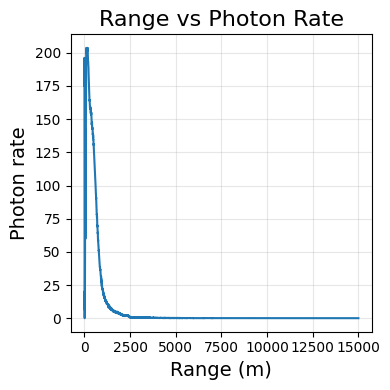

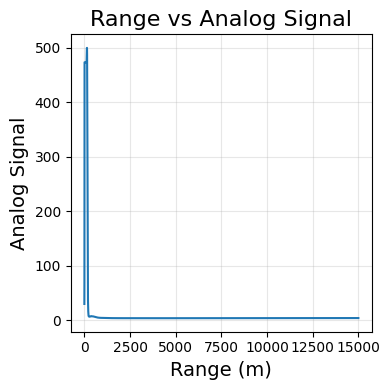

In [6]:
def plot_xy(
    df,
    xcol,
    ycol,
    *,
    title=None,
    xlabel=None,
    ylabel=None,
    xscale="linear",
    yscale="linear",
    figsize=(4, 4),
    outfile=None,
    dpi=300,
):
    # auto labels if not provided
    if title is None:
        title = f"{ycol} vs {xcol}"
    if xlabel is None:
        xlabel = xcol
    if ylabel is None:
        ylabel = ycol

    plt.figure(figsize=figsize)
    plt.plot(df[xcol], df[ycol])

    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.title(title, fontsize=16)

    plt.xscale(xscale)
    plt.yscale(yscale)

    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()

    if outfile is not None:
        plt.savefig(outfile, dpi=dpi)

    plt.show()

#plot PhotonRate vs Range
plot_xy(
    df,
    xcol="range_m",
    ycol="photon_counting",
    yscale="linear",
    title="Range vs Photon Rate",
    xlabel="Range (m)",
    ylabel="Photon rate",
    outfile="/Users/thunthita/LidarNRBPipeline/LIDar/ExampleCode/range_vs_photon_rate.png",
)
#plot PhotonRate vs Range
plot_xy(
    df,
    xcol="range_m",
    ycol="analog",
    yscale="linear",
    title="Range vs Analog Signal",
    xlabel="Range (m)",
    ylabel="Analog Signal",
    outfile="/Users/thunthita/LidarNRBPipeline/LIDar/ExampleCode/range_vs_Analog_Signal.png",
)

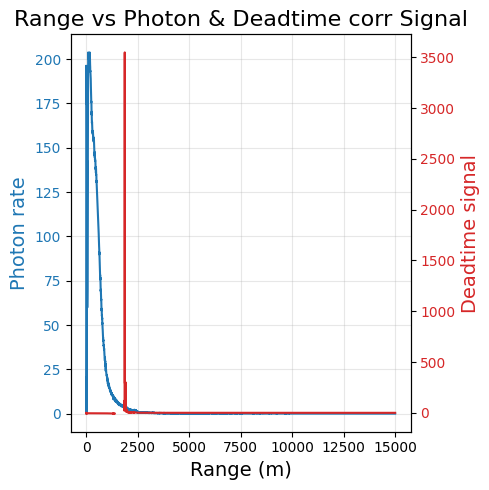

In [84]:
fig, ax1 = plt.subplots(figsize=(5,5))

# Left y-axis (Photon)
ax1.plot(df["range_m"], df["photon_counting"], color="tab:blue", label="Photon rate")
ax1.set_xlabel("Range (m)", fontsize=14)
ax1.set_ylabel("Photon rate", color="tab:blue", fontsize=14)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# Right y-axis (Analog)
ax2 = ax1.twinx()
ax2.plot(df["range_m"], df["photon_deadtime_corr"], color="tab:red", label="Analog signal")
ax2.set_ylabel("Deadtime signal", color="tab:red", fontsize=14)
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Range vs Photon & Deadtime corr Signal", fontsize=16)
plt.tight_layout()
plt.show()


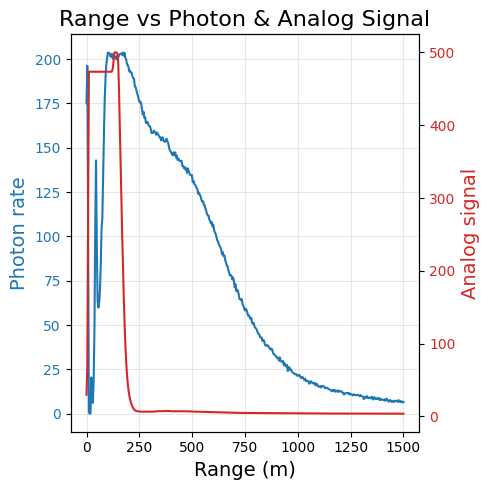

In [7]:
fig, ax1 = plt.subplots(figsize=(5,5))

# Left y-axis (Photon)
ax1.plot(df_0_1500["range_m"], df_0_1500["photon_counting"], color="tab:blue", label="Photon rate")
ax1.set_xlabel("Range (m)", fontsize=14)
ax1.set_ylabel("Photon rate", color="tab:blue", fontsize=14)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# Right y-axis (Analog)
ax2 = ax1.twinx()
ax2.plot(df_0_1500["range_m"], df_0_1500["analog"], color="tab:red", label="Analog signal")
ax2.set_ylabel("Analog signal", color="tab:red", fontsize=14)
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Range vs Photon & Analog Signal", fontsize=16)
plt.tight_layout()
plt.show()


In [8]:
# Step 1: Deadtime correction on raw photon_counting
bin_width_s = config["bin_width_ns"] * 1e-9
dead_time_s = config["dead_time_ns"] * 1e-9

df["photon_deadtime_counts"] = (
    df["photon_counting"]
    / (1 - df["photon_counting"] * dead_time_s / bin_width_s)
)
ratio_dt = df["photon_deadtime_counts"] * dead_time_s / bin_width_s
df["photon_deadtime_corr"] = np.where(
    ratio_dt < 1,
    df["photon_deadtime_counts"] / (1 - ratio_dt),
    np.nan,
)
print("Deadtime correction done  →  photon_deadtime_corr")


Deadtime correction done  →  photon_deadtime_corr


In [9]:
# Step 2: OLS regression in overlap region: analog → photon_deadtime_corr
m_overlap = df[
    (df["range_m"] >= config["overlap_r1_m"]) &
    (df["range_m"] <= config["overlap_r2_m"])
]

x = m_overlap["analog"].to_numpy(dtype=float)
y = m_overlap["photon_deadtime_corr"].to_numpy(dtype=float)
ok = np.isfinite(x) & np.isfinite(y)
k_scale, b_offset = np.polyfit(x[ok], y[ok], 1)

print(f"k_scale = {k_scale:.6f}   b_offset = {b_offset:.6f}")

# Step 3: Scaled analog
df["analog_scaled_for_glue"] = k_scale * df["analog"] + b_offset


k_scale = 0.000734   b_offset = -4.188971


In [10]:
# Step 4: Cosine blend (glue) → merged_counts_per_bin
blend_r1_m = config["overlap_r1_m"] - 100
blend_r2_m = config["overlap_r2_m"] + 100

r = df["range_m"].to_numpy(dtype=float)
w = np.zeros_like(r, dtype=float)
w[r > blend_r2_m] = 1.0
m_blend = (r >= blend_r1_m) & (r <= blend_r2_m)
w[m_blend] = 0.5 * (1.0 - np.cos(
    np.pi * (r[m_blend] - blend_r1_m) / (blend_r2_m - blend_r1_m)
))
df["weight_w"] = w

df["merged_counts_per_bin"] = (
    (1.0 - w) * df["analog_scaled_for_glue"].to_numpy(dtype=float)
    + w        * df["photon_deadtime_corr"].to_numpy(dtype=float)
)
print("Glue done  →  merged_counts_per_bin")


Glue done  →  merged_counts_per_bin


In [11]:
# Step 5: Background subtraction on merged channel
bg_row = df[
    (df["range_m"] >= config["bg_start_m"]) &
    (df["range_m"] <= config["bg_end_m"])
]
merged_bg_mean = bg_row["merged_counts_per_bin"].mean()
print("Merged background mean:", merged_bg_mean)

df["merged_bg_corr"] = df["merged_counts_per_bin"] - merged_bg_mean


Merged background mean: 0.02017690073579544


In [12]:
df

,bin_index,range_m,analog,analog_sterr,photon_counting,pc_sterr,overflow_info,SNR_analog,SNR_Photon,photon_deadtime_counts,photon_deadtime_corr,analog_scaled_for_glue,weight_w,merged_counts_per_bin,merged_bg_corr
0,0,0.00,29.89530,0.174851,175.084000,0.892927,0.0,170.975859,196.078739,-8.569828,-4.182552,-4.167030,0.0,-4.167030,-4.187207
1,1,3.75,68.51770,0.405949,196.221000,0.878221,0.0,168.784010,223.430093,-8.524880,-4.171817,-4.138684,0.0,-4.138684,-4.158861
2,2,7.50,281.50300,2.349840,108.629000,1.375130,0.0,119.796667,78.995440,-8.834363,-4.244584,-3.982371,0.0,-3.982371,-4.002548
3,3,11.25,473.53200,0.066729,0.986622,0.128929,0.0,7096.344918,7.652444,1.122134,1.300797,-3.841439,0.0,-3.841439,-3.861616
4,4,15.00,473.45700,0.000000,0.000000,0.000000,0.0,inf,NaN,0.000000,0.000000,-3.841494,0.0,-3.841494,-3.861671
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,3995,14981.25,3.99899,0.000000,0.050167,0.000000,0.0,inf,inf,0.050477,0.050791,-4.186036,1.0,0.050791,0.030614
3996,3996,14985.00,3.99940,0.000000,0.000000,0.000000,0.0,inf,NaN,0.000000,0.000000,-4.186035,1.0,0.000000,-0.020177
3997,3997,14988.75,3.99943,0.000000,0.016722,0.000000,0.0,inf,inf,0.016757,0.016791,-4.186035,1.0,0.016791,-0.003386
3998,3998,14992.50,3.99942,0.000000,0.000000,0.000000,0.0,inf,NaN,0.000000,0.000000,-4.186035,1.0,0.000000,-0.020177


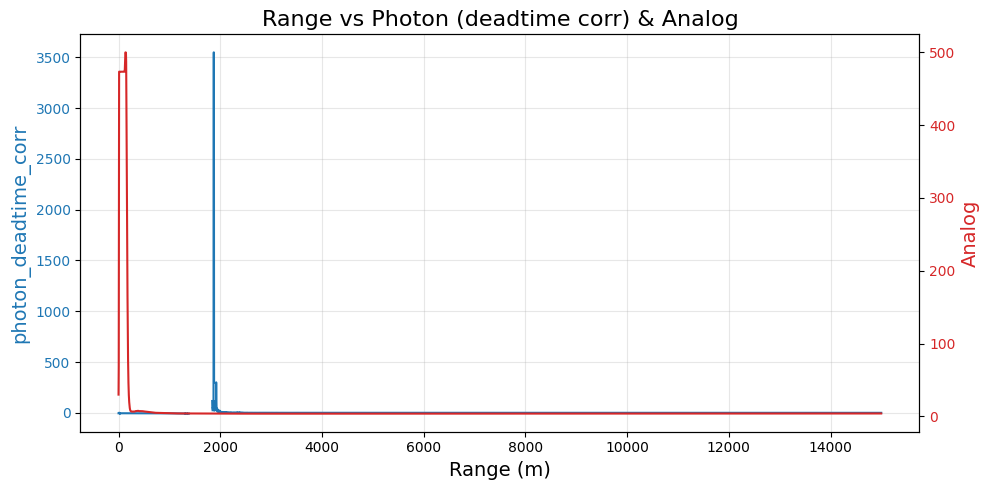

In [13]:
fig, ax1 = plt.subplots(figsize=(10,5))

# Left y-axis (Photon deadtime corrected)
ax1.plot(df["range_m"], df["photon_deadtime_corr"], color="tab:blue", label="Photon (deadtime corr)")
ax1.set_xlabel("Range (m)", fontsize=14)
ax1.set_ylabel("photon_deadtime_corr", color="tab:blue", fontsize=14)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

# Right y-axis (Analog)
ax2 = ax1.twinx()
ax2.plot(df["range_m"], df["analog"], color="tab:red", label="Analog signal")
ax2.set_ylabel("Analog", color="tab:red", fontsize=14)
ax2.tick_params(axis="y", labelcolor="tab:red")

# ax1.set_xlim(300, 1200)

plt.title("Range vs Photon (deadtime corr) & Analog", fontsize=16)
plt.tight_layout()
plt.show()


In [14]:
# Step 6: Afterpulse correction on merged_bg_corr
df["afterpulse_raw"]            = AfterPulse["afterpulse_raw"]
df["afterpulse_counts_per_bin"] = df["afterpulse_raw"] * config["bin_width_ns"] * 1e-3

df["merged_APcorr"] = df["merged_bg_corr"] - df["afterpulse_counts_per_bin"].fillna(0)
print("Afterpulse correction done  →  merged_APcorr")


Afterpulse correction done  →  merged_APcorr


In [15]:
# Step 7: Range² correction + normalise
df["range2_corrected_counts"] = df["merged_APcorr"] * df["range_m"] ** 2

mx = df["range2_corrected_counts"].max()
df["range2_norm"] = df["range2_corrected_counts"] / mx if (np.isfinite(mx) and mx != 0) else np.nan
print("Range² done  →  range2_corrected_counts, range2_norm")


Range² done  →  range2_corrected_counts, range2_norm


In [16]:
df


,bin_index,range_m,analog,analog_sterr,photon_counting,pc_sterr,overflow_info,SNR_analog,SNR_Photon,photon_deadtime_counts,photon_deadtime_corr,analog_scaled_for_glue,weight_w,merged_counts_per_bin,merged_bg_corr,afterpulse_raw,afterpulse_counts_per_bin,merged_APcorr,range2_corrected_counts,range2_norm
0,0,0.00,29.89530,0.174851,175.084000,0.892927,0.0,170.975859,196.078739,-8.569828,-4.182552,-4.167030,0.0,-4.167030,-4.187207,0.0,0.0,-4.187207,-0.000000e+00,-0.000000e+00
1,1,3.75,68.51770,0.405949,196.221000,0.878221,0.0,168.784010,223.430093,-8.524880,-4.171817,-4.138684,0.0,-4.138684,-4.158861,0.0,0.0,-4.158861,-5.848399e+01,-4.688237e-09
2,2,7.50,281.50300,2.349840,108.629000,1.375130,0.0,119.796667,78.995440,-8.834363,-4.244584,-3.982371,0.0,-3.982371,-4.002548,0.0,0.0,-4.002548,-2.251433e+02,-1.804811e-08
3,3,11.25,473.53200,0.066729,0.986622,0.128929,0.0,7096.344918,7.652444,1.122134,1.300797,-3.841439,0.0,-3.841439,-3.861616,0.0,0.0,-3.861616,-4.887357e+02,-3.917840e-08
4,4,15.00,473.45700,0.000000,0.000000,0.000000,0.0,inf,NaN,0.000000,0.000000,-3.841494,0.0,-3.841494,-3.861671,0.0,0.0,-3.861671,-8.688759e+02,-6.965148e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,3995,14981.25,3.99899,0.000000,0.050167,0.000000,0.0,inf,inf,0.050477,0.050791,-4.186036,1.0,0.050791,0.030614,NaN,NaN,0.030614,6.870954e+06,5.507945e-04
3996,3996,14985.00,3.99940,0.000000,0.000000,0.000000,0.0,inf,NaN,0.000000,0.000000,-4.186035,1.0,0.000000,-0.020177,NaN,NaN,-0.020177,-4.530728e+06,-3.631956e-04
3997,3997,14988.75,3.99943,0.000000,0.016722,0.000000,0.0,inf,inf,0.016757,0.016791,-4.186035,1.0,0.016791,-0.003386,NaN,NaN,-0.003386,-7.606546e+05,-6.097616e-05
3998,3998,14992.50,3.99942,0.000000,0.000000,0.000000,0.0,inf,NaN,0.000000,0.000000,-4.186035,1.0,0.000000,-0.020177,NaN,NaN,-0.020177,-4.535264e+06,-3.635592e-04


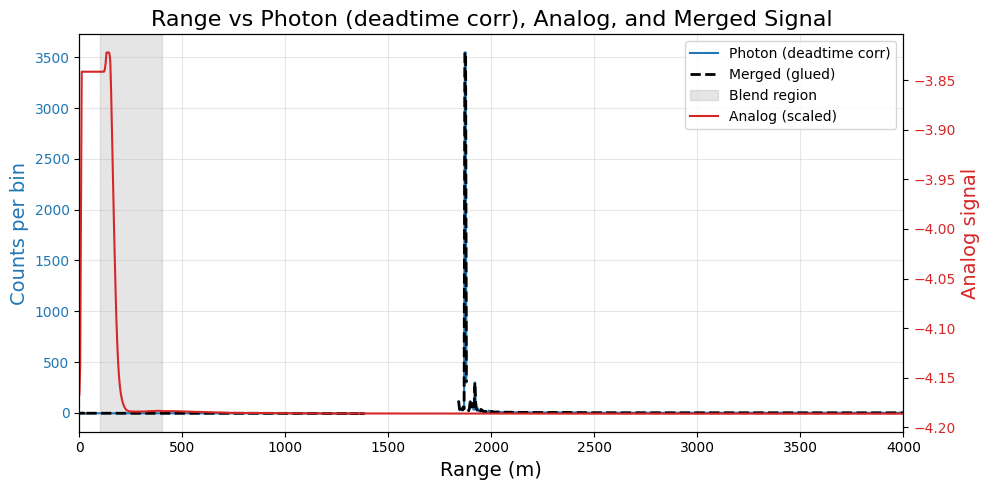

In [17]:
fig, ax1 = plt.subplots(figsize=(10,5))

ax1.plot(df["range_m"], df["photon_deadtime_corr"],
         color="tab:blue", label="Photon (deadtime corr)")
ax1.plot(df["range_m"], df["merged_counts_per_bin"],
         color="black", linestyle="--", linewidth=2, label="Merged (glued)")
ax1.set_xlabel("Range (m)", fontsize=14)
ax1.set_ylabel("Counts per bin", color="tab:blue", fontsize=14)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(df["range_m"], df["analog_scaled_for_glue"],
         color="tab:red", label="Analog (scaled)")
ax1.axvspan(blend_r1_m, blend_r2_m, color="gray", alpha=0.2, label="Blend region")
ax1.set_xlim(0, 4000)
ax2.set_ylabel("Analog signal", color="tab:red", fontsize=14)
ax2.tick_params(axis="y", labelcolor="tab:red")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")

plt.title("Range vs Photon (deadtime corr), Analog, and Merged Signal", fontsize=16)
plt.tight_layout()
plt.show()


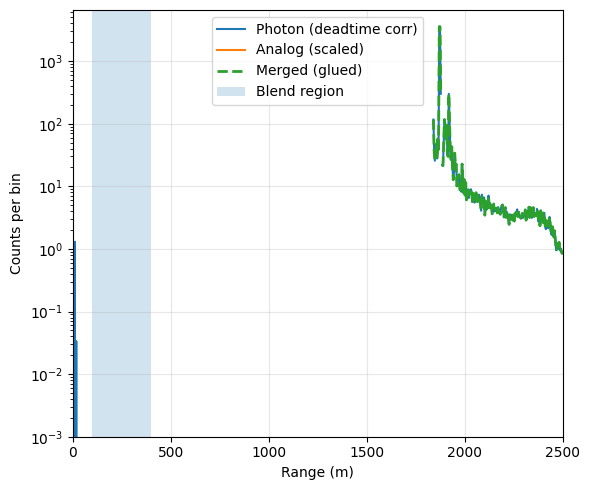

In [18]:
fig, ax = plt.subplots(figsize=(6,5))

ax.plot(df["range_m"], df["photon_deadtime_corr"], label="Photon (deadtime corr)")
ax.plot(df["range_m"], df["analog_scaled_for_glue"], label="Analog (scaled)")
ax.plot(df["range_m"], df["merged_counts_per_bin"], "--", linewidth=2, label="Merged (glued)")

ax.axvspan(blend_r1_m, blend_r2_m, alpha=0.2, label="Blend region")
ax.set_xlabel("Range (m)")
ax.set_xlim(0, 2500)
ax.set_ylabel("Counts per bin")
ax.set_yscale("log")
ax.set_ylim(1e-3, None)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


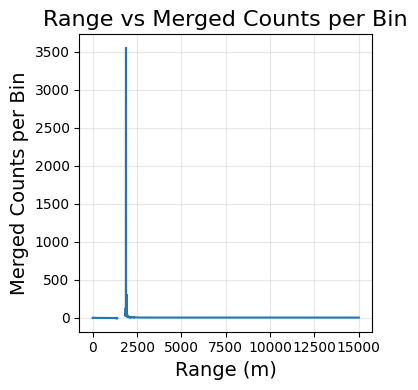

In [19]:
plot_xy(
    df,
    xcol="range_m",
    ycol="merged_counts_per_bin",
    yscale="linear",
    title="Range vs Merged Counts per Bin",
    xlabel="Range (m)",
    ylabel="Merged Counts per Bin",
    outfile="/Users/thunthita/LidarNRBPipeline/LIDar/ExampleCode/range_vs_merged_counts_per_bin.png",
)

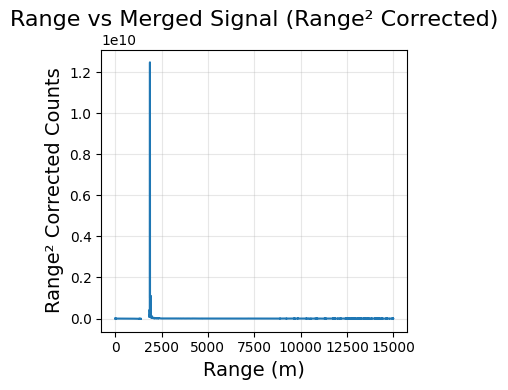

In [20]:
plot_xy(
    df,
    xcol="range_m",
    ycol="range2_corrected_counts",
    yscale="linear",
    title="Range vs Merged Signal (Range² Corrected)",
    xlabel="Range (m)",
    ylabel="Range² Corrected Counts",
    outfile="/Users/thunthita/LidarNRBPipeline/LIDar/ExampleCode/RawFilePicforExample/Prototype/range_vs_merged_counts_per_bin.png",
)

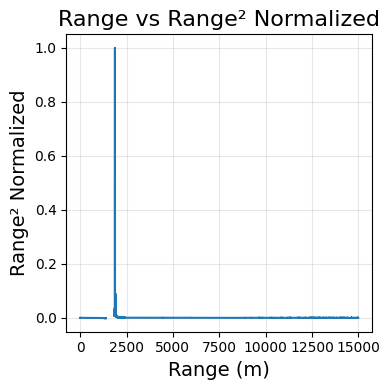

In [21]:
plot_xy(
    df,
    xcol="range_m",
    ycol="range2_norm",
    yscale="linear",
    title="Range vs Range² Normalized",
    xlabel="Range (m)",
    ylabel="Range² Normalized",
    outfile="/Users/thunthita/LidarNRBPipeline/LIDar/ExampleCode/RawFilePicforExample/Prototype/range_vs_Range2_Normalized.png",
)

In [22]:
def plot_xy_only_SNR_analog(
    df,
    xcol,
    ycol,
    *,
    title=None,
    xlabel=None,
    ylabel=None,
    xscale="linear",
    yscale="linear",
    figsize=(4, 4),
    outfile=None,
    dpi=300,
):
    # auto labels if not provided
    if title is None:
        title = f"{ycol} vs {xcol}"
    if xlabel is None:
        xlabel = xcol
    if ylabel is None:
        ylabel = ycol

    plt.figure(figsize=figsize)
    plt.plot(df[xcol], df[ycol])

    plt.xlabel(xlabel, fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.title(title, fontsize=16)

    plt.xscale(xscale)
    plt.yscale(yscale)

    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()

    if outfile is not None:
        plt.savefig(outfile, dpi=dpi)

    plt.show()
    plot_xy(
    df,
    xcol="range_m",
    ycol="SNR_analog",
    yscale="linear",
    title="Range vs SNR Analog",
    xlabel="Range (m)",
    ylabel="SNR Analog",
    outfile="/Users/thunthita/LidarNRBPipeline/LIDar/ExampleCode/RawFilePicforExample/Prototype/range_vs_SNR_analog.png",
)

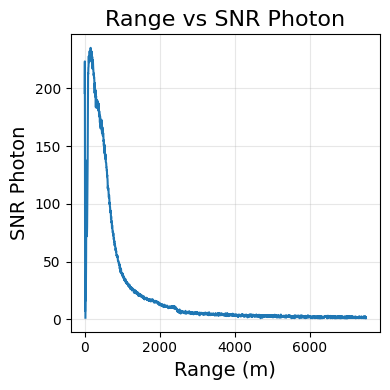

In [23]:
plot_xy(
    df,
    xcol="range_m",
    ycol="SNR_Photon",
    yscale="linear",
    title="Range vs SNR Photon",
    xlabel="Range (m)",
    ylabel="SNR Photon",
    outfile="/Users/thunthita/LidarNRBPipeline/LIDar/ExampleCode/RawFilePicforExample/Prototype/range_vs_SNR_Photon.png",
)

In [24]:
m_overlap = (
    (df["range_m"] >= config["overlap_r1_m"]) &
    (df["range_m"] <= config["overlap_r2_m"])
)

ratio = (
    df.loc[m_overlap, "analog_scaled_for_glue"] /
    df.loc[m_overlap, "photon_deadtime_corr"]
)

print("ratio mean:", ratio.mean())
print("ratio std :", ratio.std())


ratio mean: 1.0000010215186608
ratio std : 0.001030217694480144


In [25]:
df

,bin_index,range_m,analog,analog_sterr,photon_counting,pc_sterr,overflow_info,SNR_analog,SNR_Photon,photon_deadtime_counts,photon_deadtime_corr,analog_scaled_for_glue,weight_w,merged_counts_per_bin,merged_bg_corr,afterpulse_raw,afterpulse_counts_per_bin,merged_APcorr,range2_corrected_counts,range2_norm
0,0,0.00,29.89530,0.174851,175.084000,0.892927,0.0,170.975859,196.078739,-8.569828,-4.182552,-4.167030,0.0,-4.167030,-4.187207,0.0,0.0,-4.187207,-0.000000e+00,-0.000000e+00
1,1,3.75,68.51770,0.405949,196.221000,0.878221,0.0,168.784010,223.430093,-8.524880,-4.171817,-4.138684,0.0,-4.138684,-4.158861,0.0,0.0,-4.158861,-5.848399e+01,-4.688237e-09
2,2,7.50,281.50300,2.349840,108.629000,1.375130,0.0,119.796667,78.995440,-8.834363,-4.244584,-3.982371,0.0,-3.982371,-4.002548,0.0,0.0,-4.002548,-2.251433e+02,-1.804811e-08
3,3,11.25,473.53200,0.066729,0.986622,0.128929,0.0,7096.344918,7.652444,1.122134,1.300797,-3.841439,0.0,-3.841439,-3.861616,0.0,0.0,-3.861616,-4.887357e+02,-3.917840e-08
4,4,15.00,473.45700,0.000000,0.000000,0.000000,0.0,inf,NaN,0.000000,0.000000,-3.841494,0.0,-3.841494,-3.861671,0.0,0.0,-3.861671,-8.688759e+02,-6.965148e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,3995,14981.25,3.99899,0.000000,0.050167,0.000000,0.0,inf,inf,0.050477,0.050791,-4.186036,1.0,0.050791,0.030614,NaN,NaN,0.030614,6.870954e+06,5.507945e-04
3996,3996,14985.00,3.99940,0.000000,0.000000,0.000000,0.0,inf,NaN,0.000000,0.000000,-4.186035,1.0,0.000000,-0.020177,NaN,NaN,-0.020177,-4.530728e+06,-3.631956e-04
3997,3997,14988.75,3.99943,0.000000,0.016722,0.000000,0.0,inf,inf,0.016757,0.016791,-4.186035,1.0,0.016791,-0.003386,NaN,NaN,-0.003386,-7.606546e+05,-6.097616e-05
3998,3998,14992.50,3.99942,0.000000,0.000000,0.000000,0.0,inf,NaN,0.000000,0.000000,-4.186035,1.0,0.000000,-0.020177,NaN,NaN,-0.020177,-4.535264e+06,-3.635592e-04


In [26]:
#MiniMPL
MiniMPL = pd.read_csv("/Users/thunthita/LidarNRBPipeline/LIDar/RawFile/05-02-2026-DATfile/MPL_5038_202602050005.csv")
MiniMPL["range_raw"]

0       0.029979
1       0.059958
2       0.089938
3       0.119917
4       0.149896
         ...    
995    29.859330
996    29.889309
997    29.919287
998    29.949266
999    29.979246
Name: range_raw, Length: 1000, dtype: float64

In [27]:
# Select + rename columns
MiniMPL_for_process = pd.DataFrame({
    "range_raw": MiniMPL["range_raw"],
    "range (m) for NRB": MiniMPL["range_raw"]*1000,
    "range (m)": MiniMPL["range_nrb"]*1000,
    "copol_raw": MiniMPL["copol_raw"],
    "copol_snr": MiniMPL["copol_snr"],
    "copol_nrb": MiniMPL["copol_nrb"],
    "pbls": MiniMPL["pbls"],
    "Normalize copol nrb": MiniMPL["copol_nrb"]/MiniMPL["copol_nrb"].max(),
})

# Save to CSV
MiniMPL_for_process.to_csv("MiniMPL_for_process_202601050005.csv", index=False)

In [28]:
MiniMPL_for_process = pd.read_csv("MiniMPL_for_process_202601050005.csv")
MiniMPL_for_process

,range_raw,range (m) for NRB,range (m),copol_raw,copol_snr,copol_nrb,pbls,Normalize copol nrb
0,0.029979,29.979246,119.91698,23.577137,76441.770000,0.245572,2.128526,0.967897
1,0.059958,59.958490,149.89623,10.943388,35470.008000,0.243041,NaN,0.957922
2,0.089938,89.937740,179.87548,10.038107,32539.170000,0.251123,NaN,0.989776
3,0.119917,119.916980,209.85472,9.292623,30119.541000,0.253717,NaN,1.000000
4,0.149896,149.896230,239.83397,8.814949,28572.502000,0.214146,NaN,0.844034
...,...,...,...,...,...,...,...,...
995,29.859330,29859.330000,NaN,0.000714,-0.065939,NaN,NaN,NaN
996,29.889309,29889.309000,NaN,0.000669,-0.216612,NaN,NaN,NaN
997,29.919287,29919.287000,NaN,0.000684,-0.158267,NaN,NaN,NaN
998,29.949266,29949.266000,NaN,0.000729,-0.039808,NaN,NaN,NaN


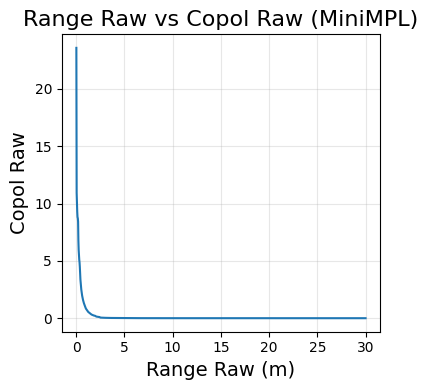

In [29]:
plot_xy(
    MiniMPL_for_process,
    xcol="range_raw",
    ycol="copol_raw",
    yscale="linear",
    title="Range Raw vs Copol Raw (MiniMPL)",
    xlabel="Range Raw (m)",
    ylabel="Copol Raw",
    outfile="/Users/thunthita/LidarNRBPipeline/LIDar/ExampleCode/RawFilePicforExample/MiniMPL/Range_Raw_vs_Copol_Raw(MiniMPL).png",
)

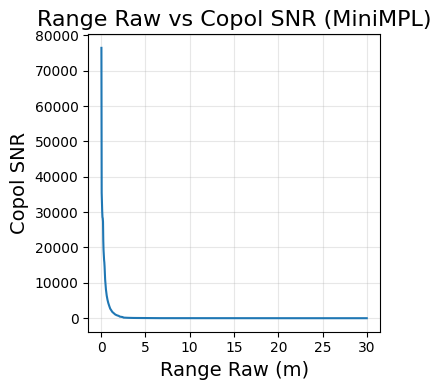

In [30]:
plot_xy(
    MiniMPL_for_process,
    xcol="range_raw",
    ycol="copol_snr",
    yscale="linear",
    title="Range Raw vs Copol SNR (MiniMPL)",
    xlabel="Range Raw (m)",
    ylabel="Copol SNR",
    outfile="/Users/thunthita/LidarNRBPipeline/LIDar/ExampleCode/RawFilePicforExample/MiniMPL/Range_Raw_vs_Copol_SNR(MiniMPL).png",
)

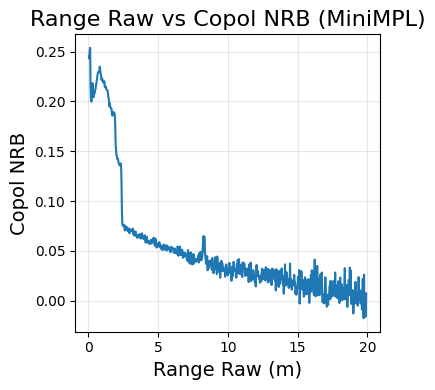

In [31]:
plot_xy(
    MiniMPL_for_process,
    xcol="range_raw",
    ycol="copol_nrb",
    yscale="linear",
    title="Range Raw vs Copol NRB (MiniMPL)",
    xlabel="Range Raw (m)",
    ylabel="Copol NRB",
    outfile="/Users/thunthita/LidarNRBPipeline/LIDar/ExampleCode/RawFilePicforExample/MiniMPL/Range_Raw_vs_Copol_NRB(MiniMPL).png",
)

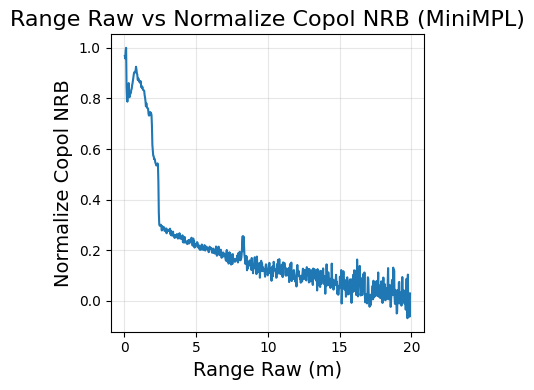

In [32]:
plot_xy(
    MiniMPL_for_process,
    xcol="range_raw",
    ycol="Normalize copol nrb",
    yscale="linear",
    title="Range Raw vs Normalize Copol NRB (MiniMPL)",
    xlabel="Range Raw (m)",
    ylabel="Normalize Copol NRB",
    outfile="/Users/thunthita/LidarNRBPipeline/LIDar/ExampleCode/RawFilePicforExample/MiniMPL/Range_Raw_vs_Normalize_copol_nrb(MiniMPL).png",
)

ต้องพยายามทำยังไงก็ได้ ให้ normalized แค่บางช่วง (ให้ความสำคัญแค่บางช่วง) เช่น ช่วง 0-3 km แล้วเอาช่วงอื่นๆ

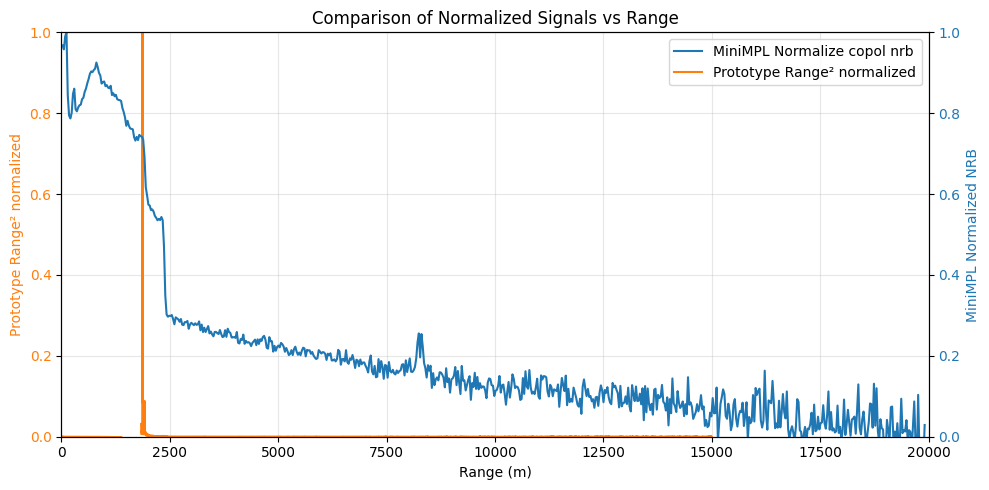

In [34]:
fig, ax1 = plt.subplots(figsize=(10,5))

# ---- Left axis (Prototype) ----
color1 = "tab:orange"

ax1.plot(
    df["range_m"],
    df["range2_norm"],
    label="Prototype Range² normalized",
    color=color1,
)

ax1.set_xlabel("Range (m)")
ax1.set_ylabel("Prototype Range² normalized", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)
ax1.set_xlim(0,20000)
ax1.set_ylim(0,1)

# ---- Right axis (MiniMPL) ----
ax2 = ax1.twinx()

color2 = "tab:blue"

ax2.plot(
    MiniMPL_for_process["range (m) for NRB"],
    MiniMPL_for_process["Normalize copol nrb"],
    label="MiniMPL Normalize copol nrb",
    color=color2,
)

ax2.set_ylabel("MiniMPL Normalized NRB", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)
ax2.set_ylim(0,1)
# ---- Title / grid ----
ax1.set_title("Comparison of Normalized Signals vs Range")
ax1.grid(True, alpha=0.3)

# ---- Combined legend (MiniMPL first) ----
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines2 + lines1, labels2 + labels1)

plt.tight_layout()
plt.show()

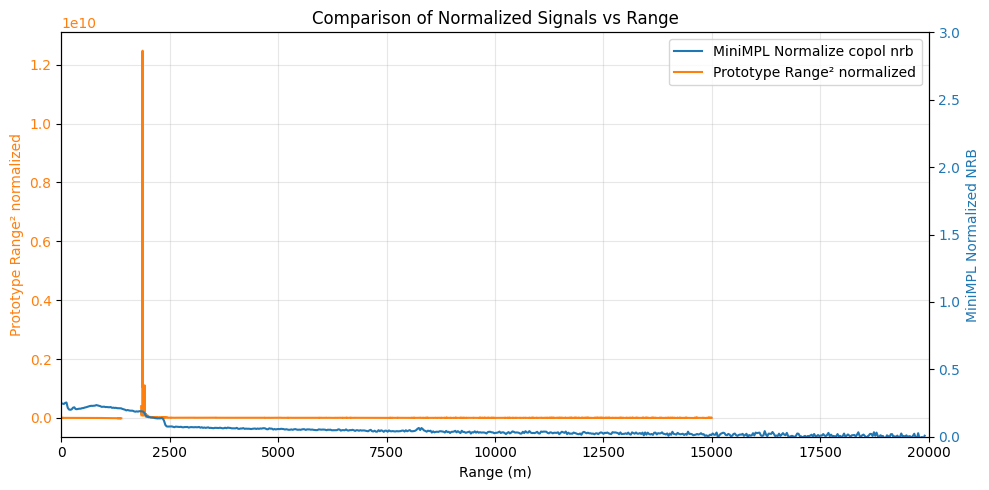

In [35]:
fig, ax1 = plt.subplots(figsize=(10,5))

# ---- Left axis (Prototype) ----
color1 = "tab:orange"

ax1.plot(
    df["range_m"],
    df["range2_corrected_counts"],
    label="Prototype Range² normalized",
    color=color1,
)

ax1.set_xlabel("Range (m)")
ax1.set_ylabel("Prototype Range² normalized", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)
ax1.set_xlim(0,20000)
# ax1.set_ylim(0,10)

# ---- Right axis (MiniMPL) ----
ax2 = ax1.twinx()

color2 = "tab:blue"

ax2.plot(
    MiniMPL_for_process["range (m) for NRB"],
    MiniMPL_for_process["copol_nrb"],
    label="MiniMPL Normalize copol nrb",
    color=color2,
)

ax2.set_ylabel("MiniMPL Normalized NRB", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)
ax2.set_ylim(0,3)
# ---- Title / grid ----
ax1.set_title("Comparison of Normalized Signals vs Range")
ax1.grid(True, alpha=0.3)

# ---- Combined legend (MiniMPL first) ----
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines2 + lines1, labels2 + labels1)

plt.tight_layout()
plt.show()

In [36]:
import numpy as np
import pandas as pd
from scipy.stats import linregress

def auto_detect_overlap_region(
    df,
    analog_col="analog",
    photon_col="photon_counting",
    range_col="range_m",
    r_min=100,
    r_max=5000,
    window_m=500,
    step_m=25,
    min_points=20,
    r2_min=0.95,
):
    results = []
    for start in np.arange(r_min, r_max - window_m + step_m, step_m):
        end = start + window_m
        d = df[
            (df[range_col] >= start) &
            (df[range_col] <= end)
        ][[range_col, analog_col, photon_col]].copy()

        # clean
        d = d.replace([np.inf, -np.inf], np.nan).dropna()
        d = d[(d[analog_col] > 0) & (d[photon_col] > 0)]
        if len(d) < min_points:
            continue

        x = d[analog_col].to_numpy()
        y = d[photon_col].to_numpy()
        slope, intercept, r, p, stderr = linregress(x, y)
        r2 = r**2

        y_fit = slope * x + intercept
        rmse = np.sqrt(np.mean((y - y_fit)**2))
        rel_rmse = rmse / np.mean(y)

        results.append({
            "start_m": start,
            "end_m": end,
            "n_points": len(d),
            "slope": slope,
            "intercept": intercept,
            "r2": r2,
            "rel_rmse": rel_rmse,
        })

    if not results:           # ← check BEFORE making DataFrame
        return None, None

    results_df = pd.DataFrame(results)

    # ── Slope stability filter (rolling std over 5 neighbours) ──────────
    results_df["slope_rolling_std"] = (
        results_df["slope"]
        .rolling(window=5, center=True)
        .std()
    )

    global_slope_std = results_df["slope"].std()

    # ── Combined candidate filter (R² + positive slope + stability) ─────
    candidates = results_df[
        (results_df["slope"] > 0) &
        (results_df["r2"] >= r2_min) &
        (results_df["slope_rolling_std"] < global_slope_std * 0.3)  # ← stability
    ].copy()

    if candidates.empty:
        # fallback 1: drop stability requirement, keep R² + slope
        candidates = results_df[
            (results_df["slope"] > 0) &
            (results_df["r2"] >= r2_min)
        ].copy()

    if candidates.empty:
        # fallback 2: just pick highest R² from everything
        best = results_df.sort_values(
            by=["r2", "rel_rmse"],
            ascending=[False, True]
        ).iloc[0]
    else:
        best = candidates.sort_values(
            by=["r2", "rel_rmse"],
            ascending=[False, True]
        ).iloc[0]

    return best, results_df


best, scan_table = auto_detect_overlap_region(
    df,
    r_min=100,
    r_max=5000,
    window_m=150,
    step_m=25,
    min_points=20,
    r2_min=0.95,
)
print(best)

start_m              725.000000
end_m                875.000000
n_points              40.000000
slope                 60.280881
intercept           -231.347416
r2                     0.995477
rel_rmse               0.012074
slope_rolling_std      3.069328
Name: 25, dtype: float64


In [37]:
df

,bin_index,range_m,analog,analog_sterr,photon_counting,pc_sterr,overflow_info,SNR_analog,SNR_Photon,photon_deadtime_counts,photon_deadtime_corr,analog_scaled_for_glue,weight_w,merged_counts_per_bin,merged_bg_corr,afterpulse_raw,afterpulse_counts_per_bin,merged_APcorr,range2_corrected_counts,range2_norm
0,0,0.00,29.89530,0.174851,175.084000,0.892927,0.0,170.975859,196.078739,-8.569828,-4.182552,-4.167030,0.0,-4.167030,-4.187207,0.0,0.0,-4.187207,-0.000000e+00,-0.000000e+00
1,1,3.75,68.51770,0.405949,196.221000,0.878221,0.0,168.784010,223.430093,-8.524880,-4.171817,-4.138684,0.0,-4.138684,-4.158861,0.0,0.0,-4.158861,-5.848399e+01,-4.688237e-09
2,2,7.50,281.50300,2.349840,108.629000,1.375130,0.0,119.796667,78.995440,-8.834363,-4.244584,-3.982371,0.0,-3.982371,-4.002548,0.0,0.0,-4.002548,-2.251433e+02,-1.804811e-08
3,3,11.25,473.53200,0.066729,0.986622,0.128929,0.0,7096.344918,7.652444,1.122134,1.300797,-3.841439,0.0,-3.841439,-3.861616,0.0,0.0,-3.861616,-4.887357e+02,-3.917840e-08
4,4,15.00,473.45700,0.000000,0.000000,0.000000,0.0,inf,NaN,0.000000,0.000000,-3.841494,0.0,-3.841494,-3.861671,0.0,0.0,-3.861671,-8.688759e+02,-6.965148e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,3995,14981.25,3.99899,0.000000,0.050167,0.000000,0.0,inf,inf,0.050477,0.050791,-4.186036,1.0,0.050791,0.030614,NaN,NaN,0.030614,6.870954e+06,5.507945e-04
3996,3996,14985.00,3.99940,0.000000,0.000000,0.000000,0.0,inf,NaN,0.000000,0.000000,-4.186035,1.0,0.000000,-0.020177,NaN,NaN,-0.020177,-4.530728e+06,-3.631956e-04
3997,3997,14988.75,3.99943,0.000000,0.016722,0.000000,0.0,inf,inf,0.016757,0.016791,-4.186035,1.0,0.016791,-0.003386,NaN,NaN,-0.003386,-7.606546e+05,-6.097616e-05
3998,3998,14992.50,3.99942,0.000000,0.000000,0.000000,0.0,inf,NaN,0.000000,0.000000,-4.186035,1.0,0.000000,-0.020177,NaN,NaN,-0.020177,-4.535264e+06,-3.635592e-04


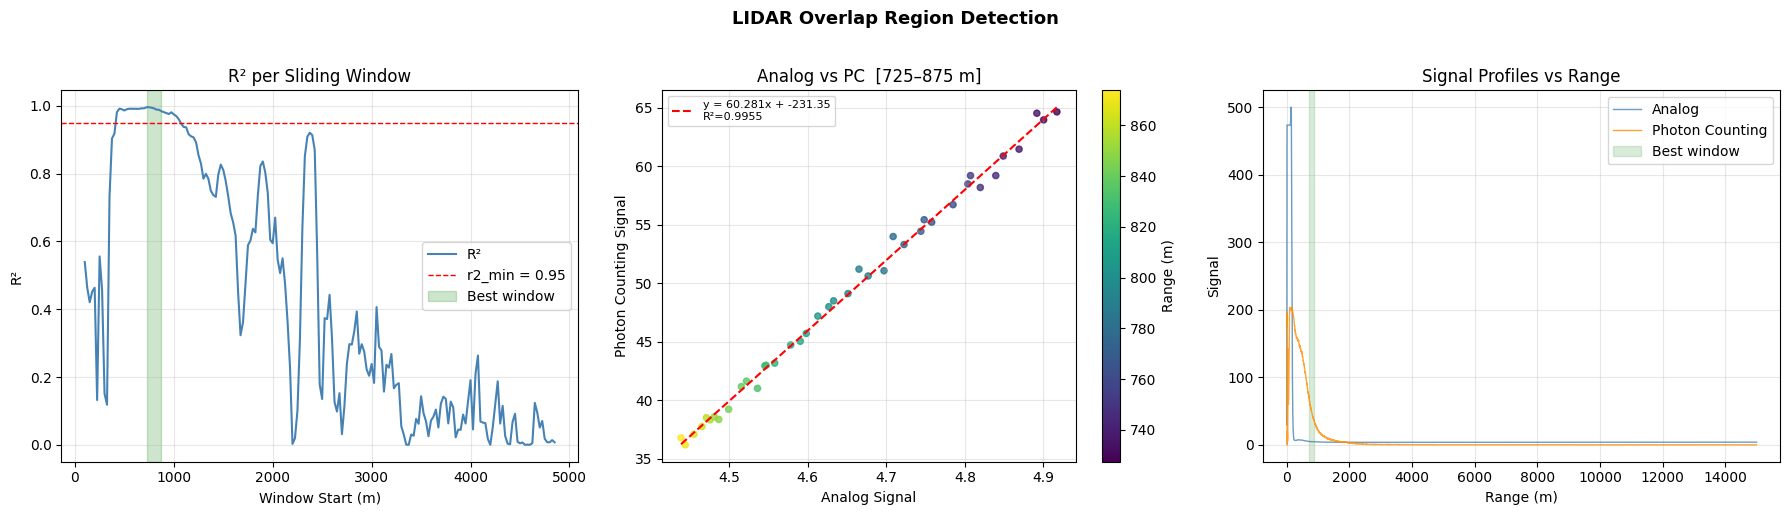

In [38]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 1. R² across all scanned windows ──────────────────────────────────────
ax1 = axes[0]
ax1.plot(scan_table["start_m"], scan_table["r2"], color="steelblue", lw=1.5, label="R²")
ax1.axhline(0.95, color="red", ls="--", lw=1, label="r2_min = 0.95")
if best is not None:
    ax1.axvspan(best["start_m"], best["end_m"], alpha=0.2, color="green", label="Best window")
ax1.set_xlabel("Window Start (m)")
ax1.set_ylabel("R²")
ax1.set_title("R² per Sliding Window")
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── 2. Analog vs Photon Counting — best window only ───────────────────────
ax2 = axes[1]
if best is not None:
    d_best = df[
        (df["range_m"] >= best["start_m"]) &
        (df["range_m"] <= best["end_m"])
    ].replace([np.inf, -np.inf], np.nan).dropna(subset=["analog", "photon_counting"])
    d_best = d_best[(d_best["analog"] > 0) & (d_best["photon_counting"] > 0)]

    ax2.scatter(d_best["analog"], d_best["photon_counting"],
                c=d_best["range_m"], cmap="viridis", s=20, alpha=0.8)

    # fitted line
    x_line = np.linspace(d_best["analog"].min(), d_best["analog"].max(), 200)
    y_line = best["slope"] * x_line + best["intercept"]
    ax2.plot(x_line, y_line, "r--", lw=1.5,
             label=f"y = {best['slope']:.3f}x + {best['intercept']:.2f}\nR²={best['r2']:.4f}")

    sm = cm.ScalarMappable(cmap="viridis",
                           norm=plt.Normalize(d_best["range_m"].min(), d_best["range_m"].max()))
    plt.colorbar(sm, ax=ax2, label="Range (m)")
    ax2.set_xlabel("Analog Signal")
    ax2.set_ylabel("Photon Counting Signal")
    ax2.set_title(f"Analog vs PC  [{best['start_m']:.0f}–{best['end_m']:.0f} m]")
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

# ── 3. Both signals vs Range — full profile ───────────────────────────────
ax3 = axes[2]
df_clean = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["analog", "photon_counting"])
df_clean = df_clean[(df_clean["analog"] > 0) & (df_clean["photon_counting"] > 0)]

ax3.plot(df_clean["range_m"], df_clean["analog"],
         color="steelblue", lw=1, alpha=0.8, label="Analog")
ax3.plot(df_clean["range_m"], df_clean["photon_counting"],
         color="darkorange", lw=1, alpha=0.8, label="Photon Counting")

if best is not None:
    ax3.axvspan(best["start_m"], best["end_m"], alpha=0.15, color="green", label="Best window")

ax3.set_xlabel("Range (m)")
ax3.set_ylabel("Signal")
ax3.set_title("Signal Profiles vs Range")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.suptitle("LIDAR Overlap Region Detection", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()